In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
import rateslib as rl
import QuantLib as ql

from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery 
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap 
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap 

# fmt: off
import Query.FixedRateBonds.adapter  # noqa: F401
# fmt: on

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

In [3]:
frb_mdp = FixedRateBondsMDP(source="USTS_PUBLICDOTCOM_WSJ_LIVE-QL")
frb_tb = FixedRateBondsTB(mdp=frb_mdp)

In [20]:
start = datetime.date(2025, 1, 1)
end = datetime.date(2025, 10, 8)
df = frb_tb.get_timeseries(
    start=start,
    end=end,
    queries=[FixedRateBondQuery(cusip="912810UA4/912810UC0", value=FixedRateBondValue.YTM)],

    # ignore_cache=True,
    n_jobs=8,
)
df

PRICING FIXED-RATE BONDS.: 100%|██████████| 193/193 [00:27<00:00,  6.93it/s]


,912810UA4/912810UC0 OUTRIGHT YTM
Date,
2025-01-02,-0.3211
2025-01-03,-0.3004
2025-01-06,-0.2311
2025-01-07,-0.3363
2025-01-08,-0.3969
...,...
2025-10-02,0.3567
2025-10-03,0.2422
2025-10-06,0.2195


In [ ]:
alias = 1150

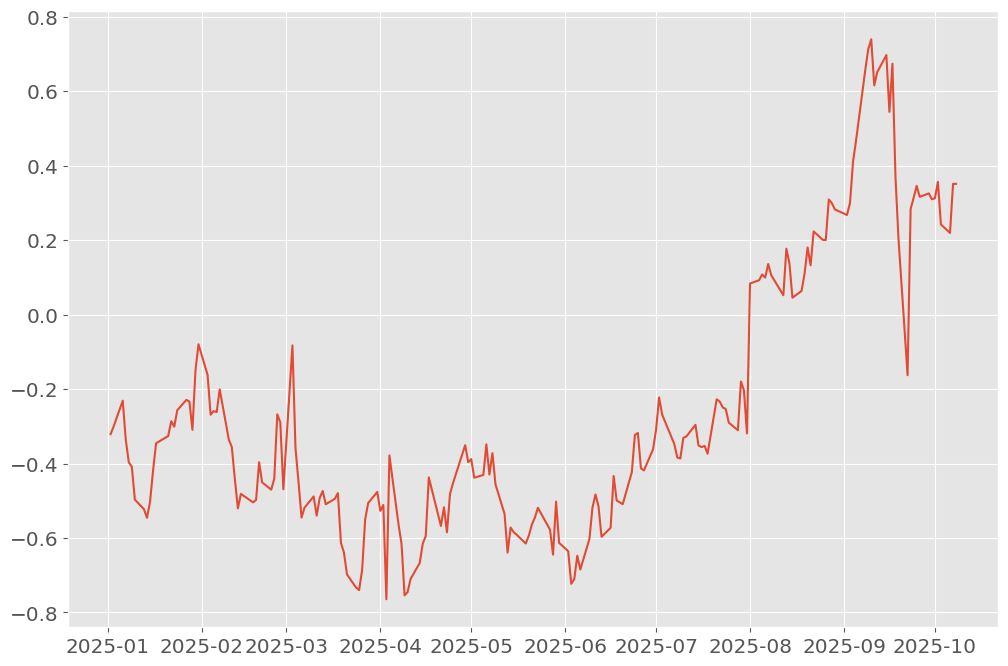

In [21]:
plt.plot(df)

In [ ]:
ql.OIS()

In [8]:
q = FixedRateBondQuery(cusip="o10/ct10", value=FixedRateBondValue.YTM, structure=FixedRateBondStructure.CURVE)
q.col_name()

'o10/ct10 CURVE YTM'

In [4]:
frb_mdp.get_pricer(dict(cusips=["o10/ct10"], timestamp=datetime.date(2024, 5, 15)))

{'o10': QLFixedRateBondPricer(_ql_frb_id='USTS', _reference_date=datetime.date(2024, 5, 15), _issue_date=datetime.date(2024, 2, 15), _maturity_date=datetime.date(2034, 2, 15), _cpn=4.0, _notional=None, _clean_price=None, _ytm=4.3615, _meta_data={'record_date': '2024-02-15', 'label': 'T 4 Feb 34', 'cusip': '91282CJZ5', 'oi': '10-Year', 'auction_date': '2024-02-07', 'issue_date': '2024-02-15', 'maturity_date': '2034-02-15', 'cpn': 4.0, 'rank': 1}),
 'ct10': QLFixedRateBondPricer(_ql_frb_id='USTS', _reference_date=datetime.date(2024, 5, 15), _issue_date=datetime.date(2024, 5, 15), _maturity_date=datetime.date(2034, 5, 15), _cpn=4.375, _notional=None, _clean_price=None, _ytm=4.3815, _meta_data={'record_date': '2024-05-15', 'label': 'T 4 3/8 May 34', 'cusip': '91282CKQ3', 'oi': '10-Year', 'auction_date': '2024-05-08', 'issue_date': '2024-05-15', 'maturity_date': '2034-05-15', 'cpn': 4.375, 'rank': 0, 'ytm_interpolated': True, 'ytm_interp_method': 'nearest', 'ytm_interp_bounds': ('2024-05-16

In [29]:
ust_pricers = frb_mdp._get_multi_pricers(cusips=["ct2/ct10"], timestamp="live")
ust_pricers

{'ct2': QLFixedRateBondPricer(_ql_frb_id='USTS', _reference_date=datetime.date(2025, 10, 8), _issue_date=datetime.date(2025, 9, 30), _maturity_date=datetime.date(2027, 9, 30), _cpn=3.5, _notional=None, _clean_price=None, _ytm=np.float64(3.572), _meta_data={'record_date': datetime.date(2025, 9, 30), 'label': 'T 3 1/2 Sep 27', 'cusip': '91282CPB1', 'oi': '2-Year', 'auction_date': datetime.date(2025, 9, 23), 'issue_date': datetime.date(2025, 9, 30), 'maturity_date': datetime.date(2027, 9, 30), 'cpn': 3.5, 'rank': 0, 'timestamp': Timestamp('2025-10-08 11:43:39+0000', tz='UTC')}),
 'ct10': QLFixedRateBondPricer(_ql_frb_id='USTS', _reference_date=datetime.date(2025, 10, 8), _issue_date=datetime.date(2025, 8, 15), _maturity_date=datetime.date(2035, 8, 15), _cpn=4.25, _notional=None, _clean_price=None, _ytm=np.float64(4.105), _meta_data={'record_date': datetime.date(2025, 8, 15), 'label': 'T 4 1/4 Aug 35', 'cusip': '91282CNT4', 'oi': '10-Year', 'auction_date': datetime.date(2025, 8, 6), 'issue

In [34]:
# cusip = "91282CNT4"
risk = 50_000

tenor = "ct5/ct30", FixedRateBondStructure.CURVE 
# tenor = "91282CNT4"
timestamp = "live"
# timestamp = datetime.date(2025, 10, 1)

query = FixedRateBondQuery(cusip=tenor[0], structure=tenor[1], structure_kwargs={"bpv": 10_000})
pricer = frb_mdp._get_multi_pricers(cusips=[query.cusip], timestamp=timestamp)
pkg, rws = query.resolve_package(pricer_or_curve=pricer)
vmap = query.build_value_map(pricer_or_curve=pricer, package=pkg, risk_weights=rws)

In [36]:
pkg, rws

([<QuantLib.QuantLib.FixedRateBond; proxy of <Swig Object of type 'ext::shared_ptr< FixedRateBond > *' at 0x000001405C168540> >,
  <QuantLib.QuantLib.FixedRateBond; proxy of <Swig Object of type 'ext::shared_ptr< FixedRateBond > *' at 0x000001405C4F0F60> >],
 [np.float64(-1.0), np.float64(1.0)])

In [37]:
# vmap.apply(FixedRateBondValue.NPV)
vmap.apply(FixedRateBondValue.YTM)
# vmap.apply(FixedRateBondValue.CLEAN_PRICE)

np.float64(99.29999999999998)

In [64]:
pricer

{'91282CNT4': QLFixedRateBondPricer(_ql_frb_id='USTS', _reference_date=datetime.date(2025, 9, 10), _issue_date=datetime.date(2025, 8, 15), _maturity_date=datetime.date(2035, 8, 15), _cpn=4.25, _notional=None, _clean_price=None, _ytm=4.033482, _meta_data={'record_date': '2025-08-15', 'label': 'T 4 1/4 Aug 35', 'cusip': '91282CNT4', 'oi': '10-Year', 'auction_date': '2025-08-06', 'issue_date': '2025-08-15', 'maturity_date': '2035-08-15', 'cpn': 4.25, 'rank': 0})}